# Plot D4.5 analysis

In [96]:
here::i_am("thesis/D45_analysis_plotting.ipynb")

source(here::here("settings.R"))
source(here::here("utils.R"))
library(Seurat)
library(dplyr)

here() starts at /rds/project/rds-SDzz0CATGms/users/bt392/10_Eomes_invitro_gut/code

Attaching SeuratObject


Attaching package: ‘Seurat’


The following object is masked from ‘package:SummarizedExperiment’:

    Assays




In [62]:
args = list()
args$indir = file.path(io$basedir, 'results/rna_atac/clustering/')
args$outdir = file.path(io$basedir, 'thesis/D45')
dir.create(args$outdir, showWarnings = F, recursive = T)

In [49]:
meta = fread(file.path(args$indir, 'd45_celltypes.txt.gz'))
umap = fread(file.path(args$indir, 'd45_umap.txt.gz'))

In [50]:
meta = merge(meta, umap, by = 'cell') %>%
    .[,genotype := gsub('_KO', ' KD', genotype)]

In [89]:
p1 = ggplot(meta, aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void() + 
    theme(legend.key.size = unit(1.2, "mm"))

p2 = ggplot(copy(meta)[genotype == 'Eomes KD'], aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(data = meta[genotype == 'WT'], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void() + theme(legend.position = 'none')

p3 = ggplot(copy(meta)[genotype == 'WT'], aes(umap1, umap2, color = celltype_manual)) + 
    ggrastr::rasterize(geom_point(data = meta[genotype == 'Eomes KD'], color = 'grey90', size = -0.2), dpi = 600) + 
    ggrastr::rasterize(geom_point(size = -0.2), dpi = 600) + 
    guides(color = guide_legend(override.aes = list(size = 2.5))) + # Set legend dot size 
    theme_void()  + theme(legend.position = 'none')

meta_props = meta %>% copy() %>%
    .[, tot := .N, by = 'genotype'] %>%
    .[, prop := .N/tot, by = c('celltype_manual', 'genotype')]

p4 = ggplot(meta_props, aes(celltype_manual, prop * 100, fill = genotype)) +
    geom_bar(position = 'dodge', stat = 'identity') + 
    scale_fill_manual(values = c('Eomes KD' = 'red', 'WT' = 'black')) +
    scale_y_continuous(expand = c(0,0,0.05,0)) + 
    scale_x_discrete(limits = c(
                                'Paraxial Mesoderm', 
                                'Somitic Mesoderm', 
                                'Ectoderm-like',
                                'unknown',
                                'PGC',
                                'Notochord', 
                                'DE/Gut'
                                )) + 
    ylab('% of genotype') + 
    theme_bw() + 
    theme(axis.text = element_text(color = 'black'),
          axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
          axis.title.x = element_blank())

options(repr.plot.width = 25)
# ggarrange(p1, p2, p3, p4, ncol = 4, align = 'h')
                      
# p4

In [92]:
ggsave(file.path(args$outdir, 'UMAPs_proportions.pdf'), 
       plot = ggarrange(cowplot::ggdraw(get_legend(p1)), p2, p3, p4, ncol = 4, widths = c(0.4, 0.8, 0.8, 1)),
       width = 250, 
       height = 60, 
       units = "mm")

In [97]:
# load sce
rna.sce <- load_SingleCellExperiment(io$rna.sce, normalise = TRUE, cells = meta$cell)
colData(rna.sce) = meta %>% as.data.frame() %>% tibble::column_to_rownames('cell') %>% DataFrame()

# Convert to Seurat
seurat = as.Seurat(rna.sce)

In [98]:
Idents(seurat) = seurat$celltype_manual

In [100]:
markers <- FindAllMarkers(seurat, only.pos = TRUE)

Calculating cluster Ectoderm-like

Calculating cluster Somitic Mesoderm

Calculating cluster Paraxial Mesoderm

Calculating cluster PGC

Calculating cluster unknown

Calculating cluster Notochord

Calculating cluster DE/Gut



ERROR: Error in ungroup(.): could not find function "ungroup"


In [101]:
head(markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
Sema3e,0,1.1254647,0.688,0.165,0,Ectoderm-like,Sema3e
Slc2a3,0,1.0625779,0.863,0.303,0,Ectoderm-like,Slc2a3
Slc2a1,0,1.0181860,0.920,0.542,0,Ectoderm-like,Slc2a1
Xkr4,0,0.9888577,0.725,0.218,0,Ectoderm-like,Xkr4
Nrxn1,0,0.8089563,0.445,0.072,0,Ectoderm-like,Nrxn1
Frem2,0,0.7919927,0.782,0.287,0,Ectoderm-like,Frem2


In [104]:
markers %>%
    group_by(cluster) %>%
    # dplyr::filter(avg_log2FC > 1) %>%
    slice_head(n = 5) %>%
    ungroup() -> top5

In [105]:
seurat$celltype_genotype = paste0(seurat$celltype_manual, '-', gsub('Eomes ', '', seurat$genotype))

In [ ]:
    '0' = 'Somitic Mesoderm', # Dll1 & Tbx6 + label transfer
    '1' = 'Paraxial Mesoderm', # Ebf1, Cdh11 & Fbn2 + label transfer
    '2' = 'Notochord', # Chrd, T, Foxa2, Slit2
    '3' = 'Ectoderm-like', # but Wnt8a, Sema3e, Fgfbp3 == ectoderm!! But also some notochord markers
    '4' = 'DE/Gut', # 
    '5' = 'PGC', # Dppa3 == stella & prdm1 == blimp1
    '6' = 'unknown'

In [111]:
paste0(unique(seurat$celltype), c('-KD', '-WT'))

[1] "Nascent_mesoderm-KD"               "Somitic_mesoderm-WT"              
 [3] "Paraxial_mesoderm-KD"              "Rostral_neurectoderm-WT"          
 [5] "PGC-KD"                            "Def._endoderm-WT"                 
 [7] "Forebrain_Midbrain_Hindbrain-KD"   "Caudal_neurectoderm-WT"           
 [9] "Intermediate_mesoderm-KD"          "Caudal_Mesoderm-WT"               
[11] "NMP-KD"                            "Spinal_cord-WT"                   
[13] "Mixed_mesoderm-KD"                 "Caudal_epiblast-WT"               
[15] "Surface_ectoderm-KD"               "Pharyngeal_mesoderm-WT"           
[17] "Haematoendothelial_progenitors-KD" "Primitive_Streak-WT"              
[19] "Neural_crest-KD"                   "Parietal_endoderm-WT"             
[21] "Endothelium-KD"                    "Epiblast-WT"                      
[23] "Notochord-KD"                      "Gut-WT"                           
[25] "Anterior_Primitive_Streak-KD"      "Blood_progenitors_1-WT"           
[27] "Visceral_endoderm-KD"

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


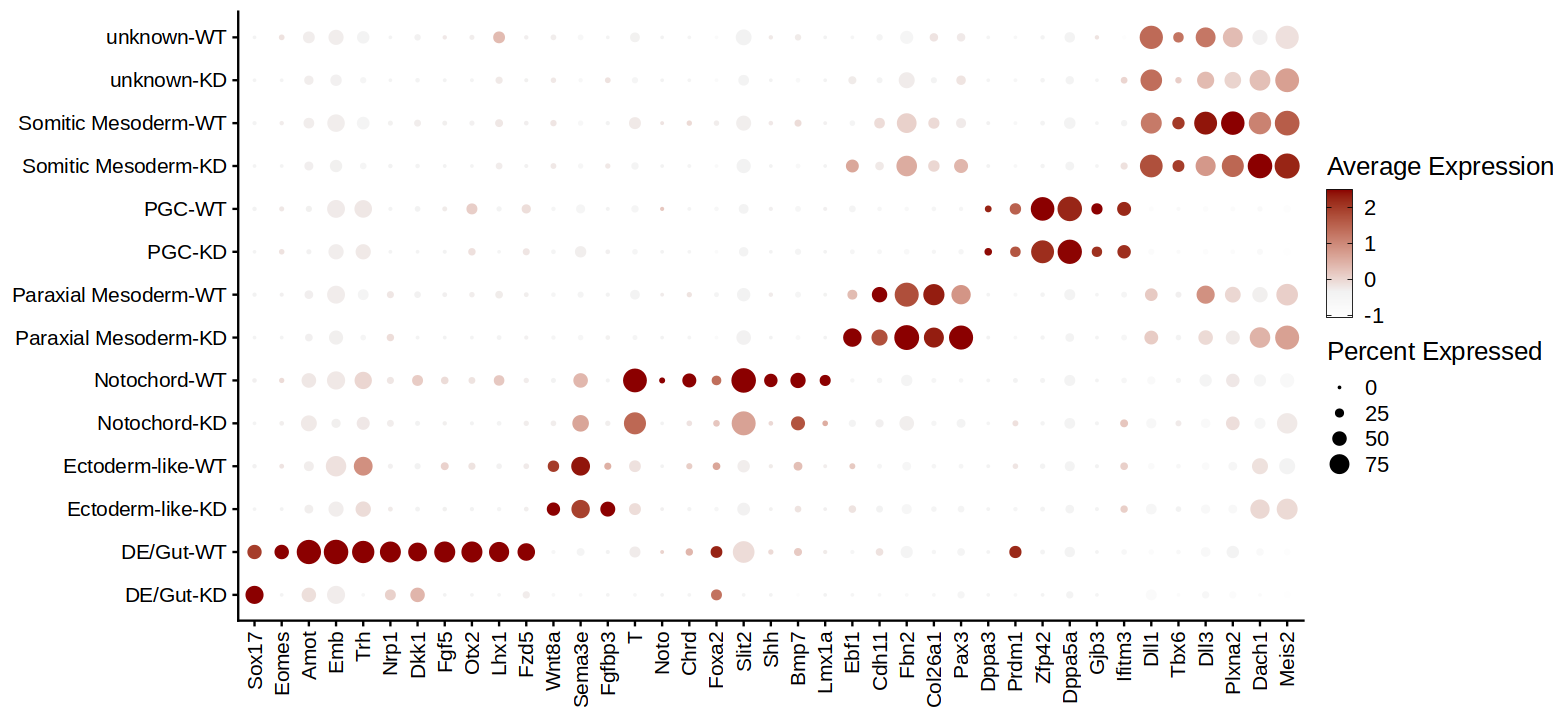

In [133]:
features = c(
    'Sox17', 'Eomes', 'Amot', 'Emb', 'Trh', 'Nrp1', 'Dkk1', 'Fgf5', 'Otx2', 'Lhx1', 'Fzd5',  # DE/gut
    'Wnt8a', 'Sema3e', 'Fgfbp3', # Ectoderm-like
    'T', 'Noto','Chrd', 'Foxa2', 'Slit2', 'Shh', 'Bmp7', 'Lmx1a', # Notochord
    'Ebf1', 'Cdh11', 'Fbn2', 'Col26a1', 'Pax3', # Parax. Mes.
    'Dppa3', 'Prdm1', 'Zfp42', 'Dppa5a','Gjb3', 'Ifitm3', # PGC
    'Dll1', 'Tbx6', 'Dll3', 'Plxna2', 'Dach1', 'Meis2' # Som. Mes.
)

options(repr.plot.width=13, repr.plot.height=6)
p = DotPlot(seurat, features = features, group.by = 'celltype_genotype') + 
    # scale_color_gradient(low='white', high='darkred', name='Average Expression') + 
    scale_color_gradientn(colours = c('white', 'grey95','darkred'), values = c(0, 0.2,1), name='Average Expression') + 
    guides(color = guide_colourbar(
         # barwidth = 0.5, barheight = 2.5,
        frame.colour = "black", 
        ticks.colour = "black"
    )) + 
    RotatedAxis() +
    ylab('celltype genotype') + xlab('') +
    theme(text=element_text(size=15), 
                         axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5),
                         axis.text.y=element_text(hjust=1),
         axis.title = element_blank())

p

In [137]:
ggsave(file.path(args$outdir, 'd45_expression.pdf'), 
       plot = p,
       width = 270, 
       height = 95, 
       units = "mm")